# ML Project

## Section 61s Group 5

##

# Importing necessary python packages

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
# Apply the default theme
sns.set_theme()

# Reading the data

In [166]:
df=pd.read_csv('student_depression_dataset.csv')

# Exploring the data

In [167]:
df.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,'Less than 5 hours',Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,'7-8 hours',Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,'7-8 hours',Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,'Less than 5 hours',Moderate,LLB,Yes,2.0,5.0,No,1


In [168]:
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


In [169]:
df.shape

(27901, 18)

In [170]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [172]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


In [173]:
# Calculate the counts of each class
class_counts = df['Depression'].value_counts()

print("Counts of each class:")
print(class_counts)

# Calculate the ratio
ratio = class_counts[0] / class_counts[1] if class_counts[0] > class_counts[1] else class_counts[1] / class_counts[0]

print(f"\nRatio (larger count / smaller count): {ratio}")

# Determine if data is balanced
if ratio > 1.5:
    print("The data is unbalanced.")
else:
    print("The data is balanced.")


Counts of each class:
Depression
1    16336
0    11565
Name: count, dtype: int64

Ratio (larger count / smaller count): 1.4125378296584523
The data is balanced.


In [174]:
df_new= df.drop(['id','Profession','City'],axis=1)
df_new.head(5)

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [175]:
df_new.shape

(27901, 15)

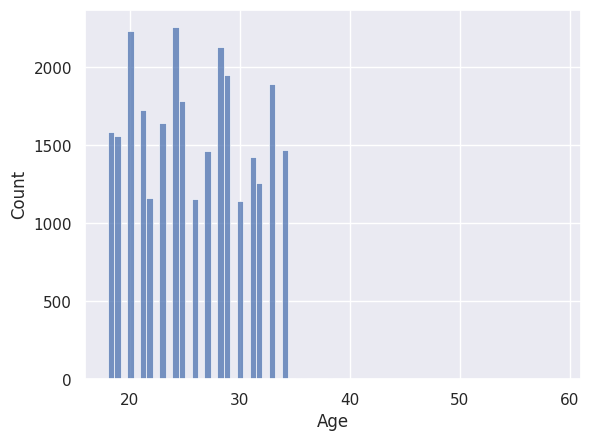

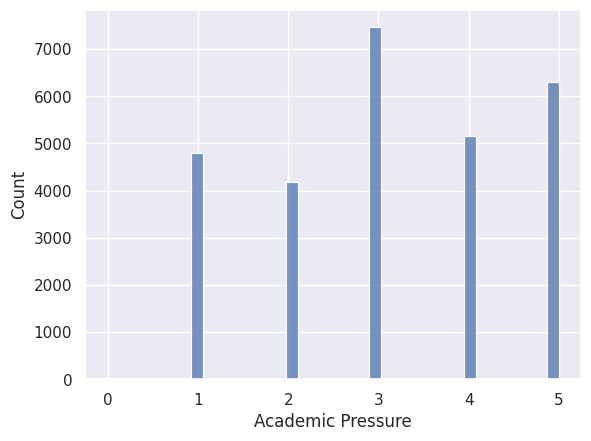

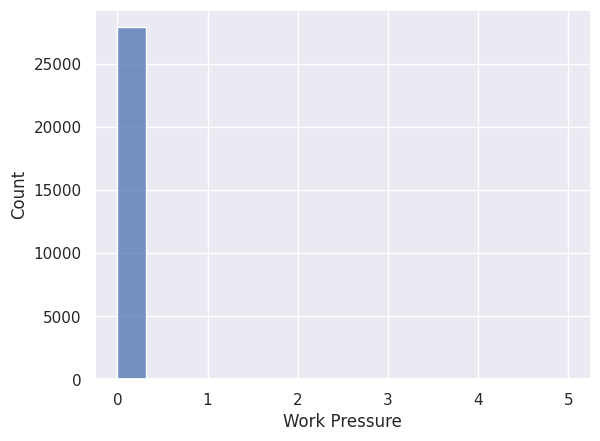

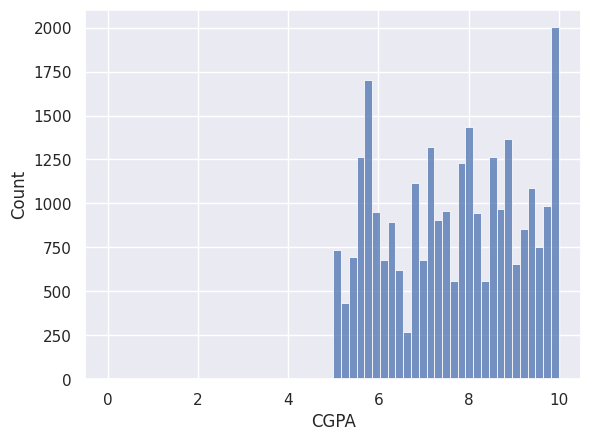

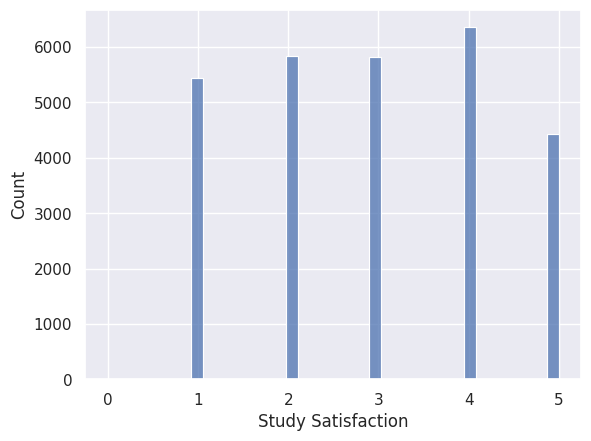

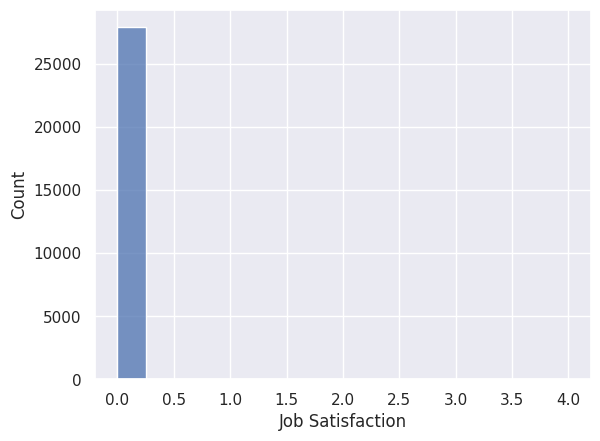

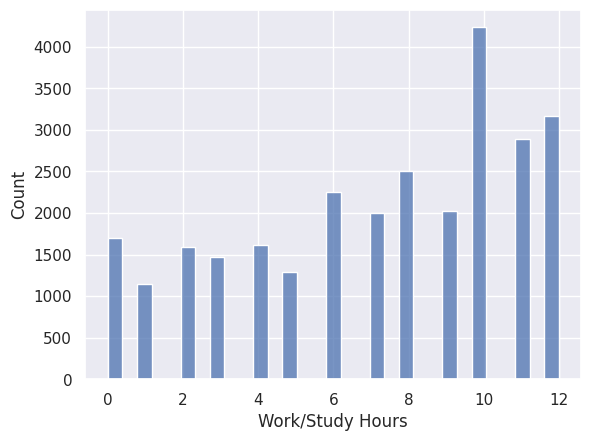

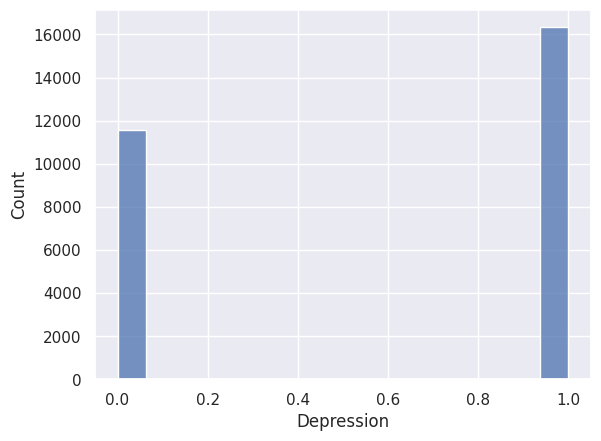

In [176]:
for i in df_new.select_dtypes(include='number').columns:
    sns.histplot(data=df_new,x=i)
    plt.show()

# Preprocessing :

## Missing Value

In [177]:
df_new.isnull().sum()

,0
Gender,0
Age,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Degree,0


In [178]:
df_new.nunique()

,0
Gender,2
Age,34
Academic Pressure,6
Work Pressure,3
CGPA,332
Study Satisfaction,6
Job Satisfaction,5
Sleep Duration,5
Dietary Habits,4
Degree,28


## Duplicated Values

In [179]:
df_new.duplicated().sum()

np.int64(0)

## Outlier Detection

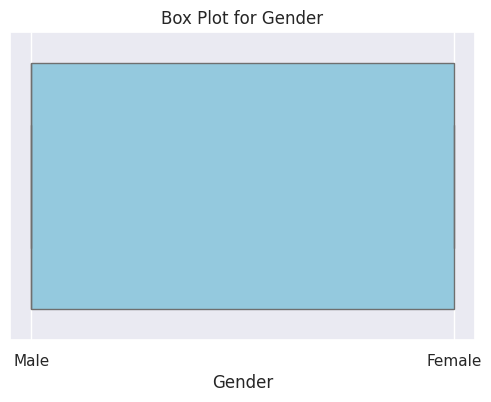

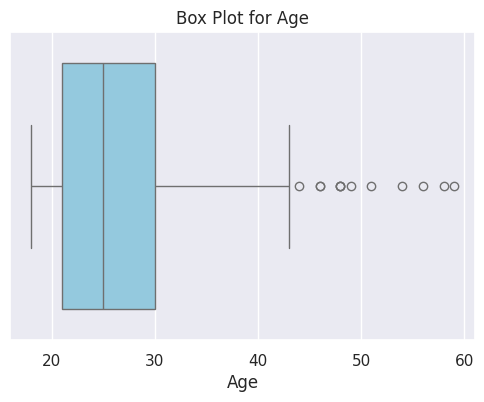

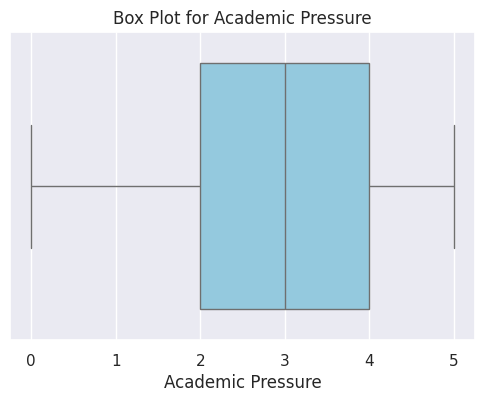

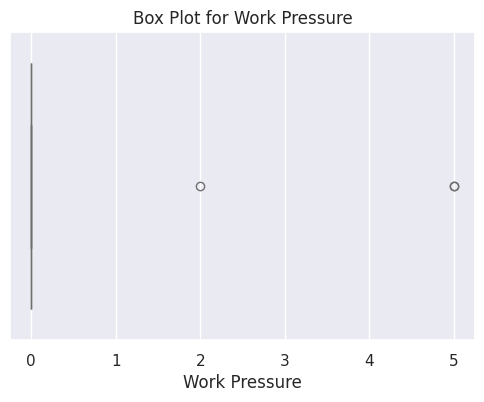

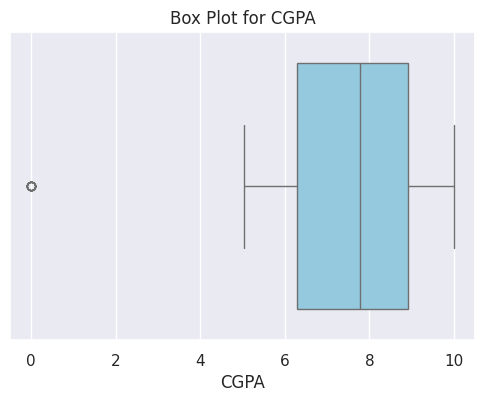

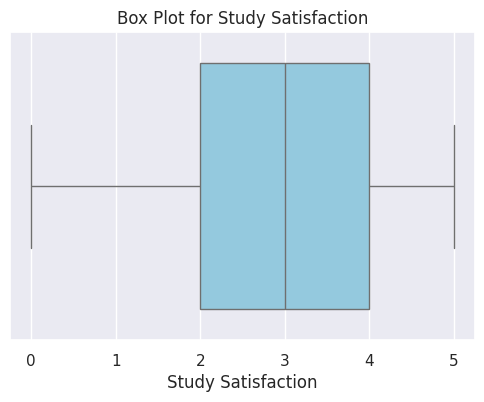

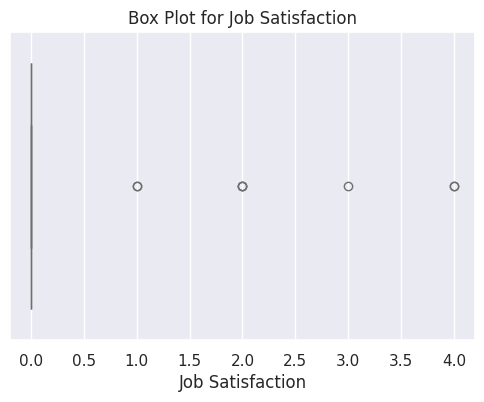

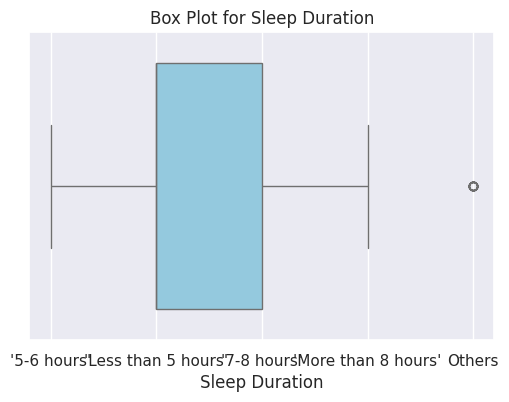

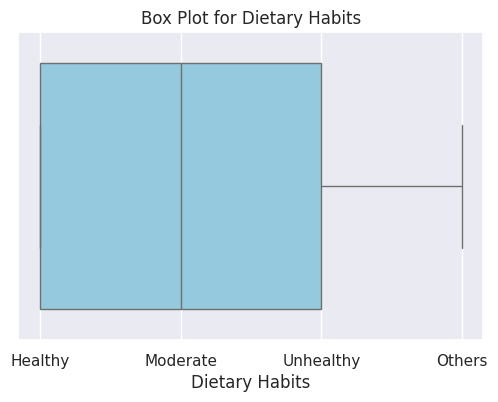

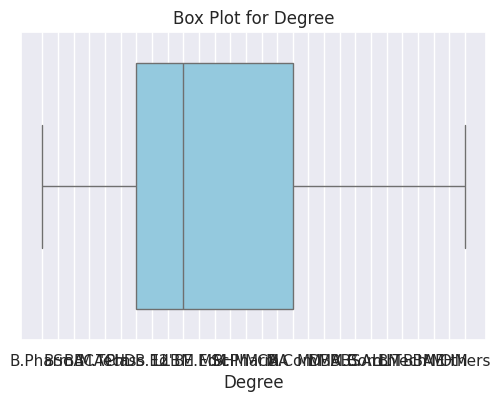

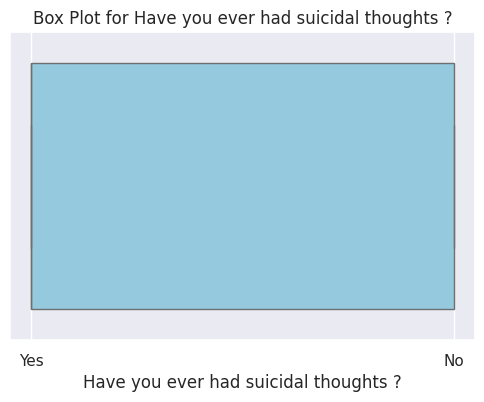

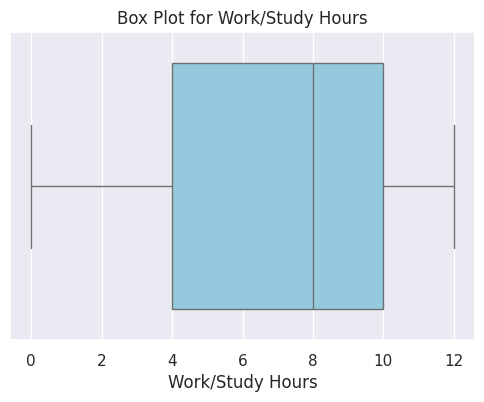

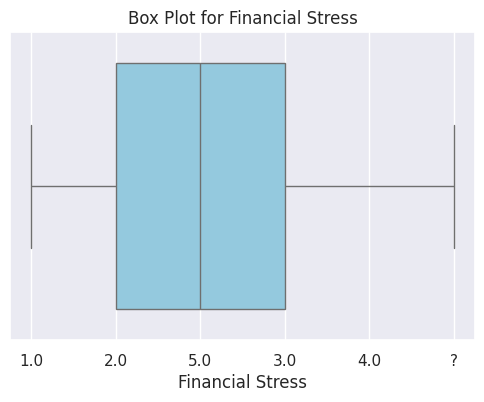

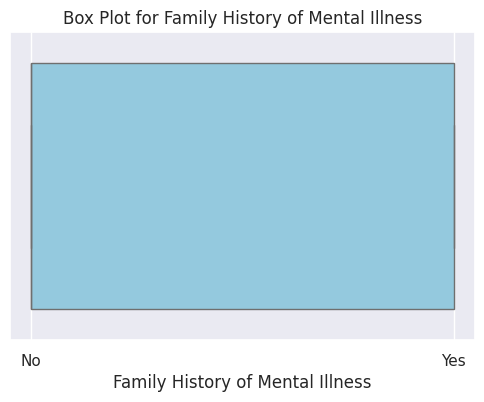

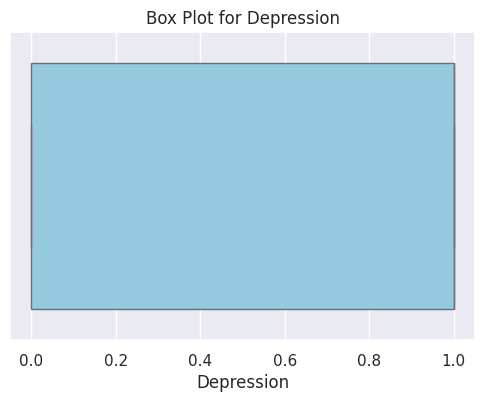

In [180]:
for column in df_new.columns:
    plt.figure(figsize=(6, 4))
    try:
        # Create boxplot for the column
        sns.boxplot(x=df_new[column], color='skyblue')
        plt.title(f'Box Plot for {column}')
        plt.xlabel(column)
        plt.show()
    except TypeError:
        # Handle columns that are not numerical
        print(f"Skipping column '{column}' as it is not numerical.")


In [181]:

numeric_cols = df_new.select_dtypes(include=['float64', 'int64']).columns


Q1 = df_new[numeric_cols].quantile(0.25)
Q3 = df_new[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

IQR

,0
Age,9.00
Academic Pressure,2.00
Work Pressure,0.00
CGPA,2.63
Study Satisfaction,2.00
Job Satisfaction,0.00
Work/Study Hours,6.00
Depression,1.00


In [182]:
# count number of outliers for each column
((df_new[numeric_cols] < (Q1 - 1.5 * IQR)) |(df_new[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

,0
Age,12
Academic Pressure,0
Work Pressure,3
CGPA,9
Study Satisfaction,0
Job Satisfaction,8
Work/Study Hours,0
Depression,0


In [183]:
Q1 = df_new['Work Pressure'].quantile(0.25)  # First quartile
Q3 = df_new['Work Pressure'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df_new[(df_new['Work Pressure'] < lower_bound) | (df_new['Work Pressure'] > upper_bound)]
print(outliers['Work Pressure'])


4365     5.0
14855    2.0
25746    5.0
Name: Work Pressure, dtype: float64


In [184]:
Q1 = df_new['Age'].quantile(0.25)  # First quartile
Q3 = df_new['Age'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df_new[(df['Age'] < lower_bound) | (df_new['Age'] > upper_bound)]
print(outliers['Age'])


2909     58.0
3436     49.0
4386     51.0
5537     44.0
9006     46.0
9238     59.0
13499    54.0
13618    48.0
14819    56.0
18766    46.0
25202    48.0
27334    48.0
Name: Age, dtype: float64


In [185]:
Q1 = df_new['CGPA'].quantile(0.25)  # First quartile
Q3 = df_new['CGPA'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df_new[(df_new['CGPA'] < lower_bound) | (df_new['CGPA'] > upper_bound)]
print(outliers['CGPA'])


4365     0.0
10407    0.0
11489    0.0
13909    0.0
14855    0.0
20913    0.0
21805    0.0
25746    0.0
26719    0.0
Name: CGPA, dtype: float64


In [186]:
Q1 = df_new['CGPA'].quantile(0.25)  # First quartile
Q3 = df_new['CGPA'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df_new[(df_new['CGPA'] < lower_bound) | (df_new['CGPA'] > upper_bound)]
print(outliers['CGPA'])

4365     0.0
10407    0.0
11489    0.0
13909    0.0
14855    0.0
20913    0.0
21805    0.0
25746    0.0
26719    0.0
Name: CGPA, dtype: float64


In [187]:

Q1 = df_new['Job Satisfaction'].quantile(0.25)  # First quartile
Q3 = df_new['Job Satisfaction'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df_new[(df['Job Satisfaction'] < lower_bound) | (df_new['Job Satisfaction'] > upper_bound)]
print(outliers['Job Satisfaction'])

292      3.0
4365     4.0
13909    2.0
14855    1.0
20913    1.0
23141    2.0
25746    4.0
26719    2.0
Name: Job Satisfaction, dtype: float64


The Boxplot and IQR show how to identify an outlier. Based on that, we see four features that indicate outliers: age, CGPA, work pressure and Job Satisfaction. However, since our data shows student depression and our defres range from class 12 to PhD and more, the age and work pressure of these students vary, and a zero CGPA is considered a rare case, but it indicates that the student dropped out or did not participate.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Academic Pressure'}>,
        <Axes: title={'center': 'Work Pressure'}>],
       [<Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Study Satisfaction'}>,
        <Axes: title={'center': 'Job Satisfaction'}>],
       [<Axes: title={'center': 'Work/Study Hours'}>,
        <Axes: title={'center': 'Depression'}>, <Axes: >]], dtype=object)

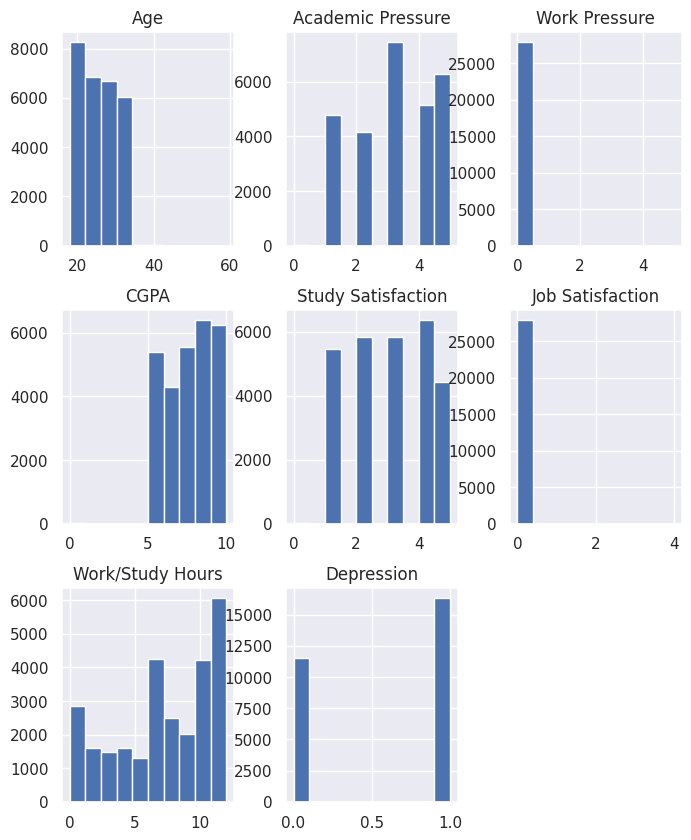

In [188]:
# to check data distribution for all columns
df_new.hist(figsize=(8,10))

# Relationship Analysis

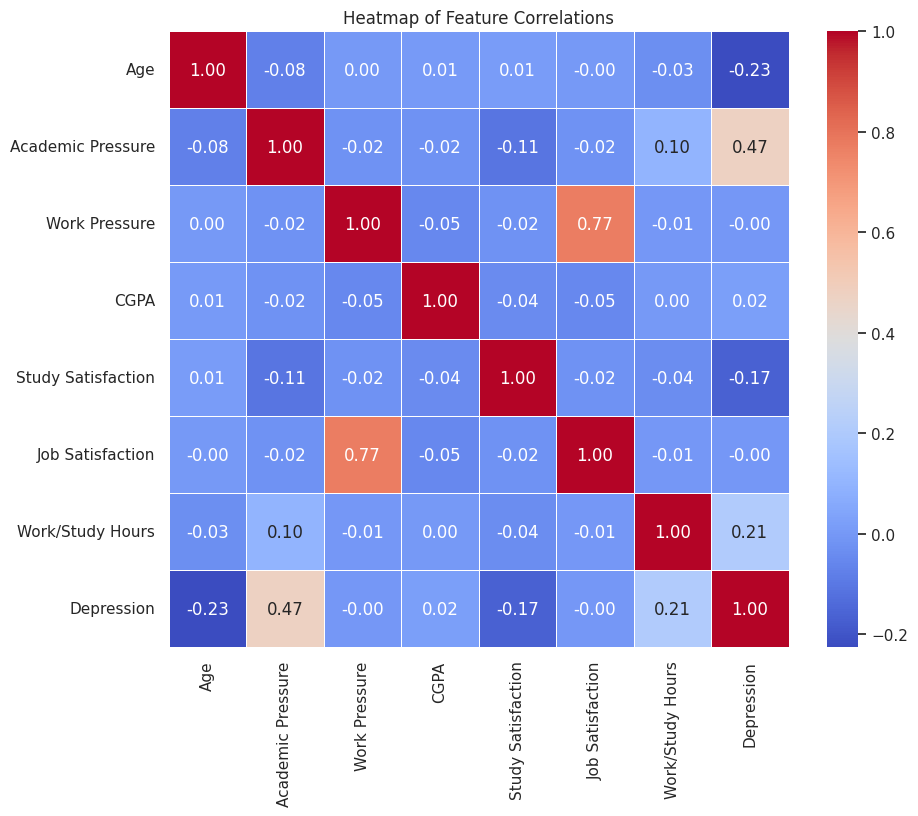

In [189]:
correlation_matrix = df_new[numeric_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

# Add title and labels
plt.title('Heatmap of Feature Correlations')
plt.show()


The heatmap represents the correlation between numerical values, indicating the dependency between variables. For example, 'Work Pressure' and 'Job Satisfaction' exhibit a strong positive correlation with a value of 0.77. This means that as one variable increases, the other variable also tends to increase. Meanwhile, a negative correlation, such as -0.11
, suggests that as one variable increases, the other decreases in value.

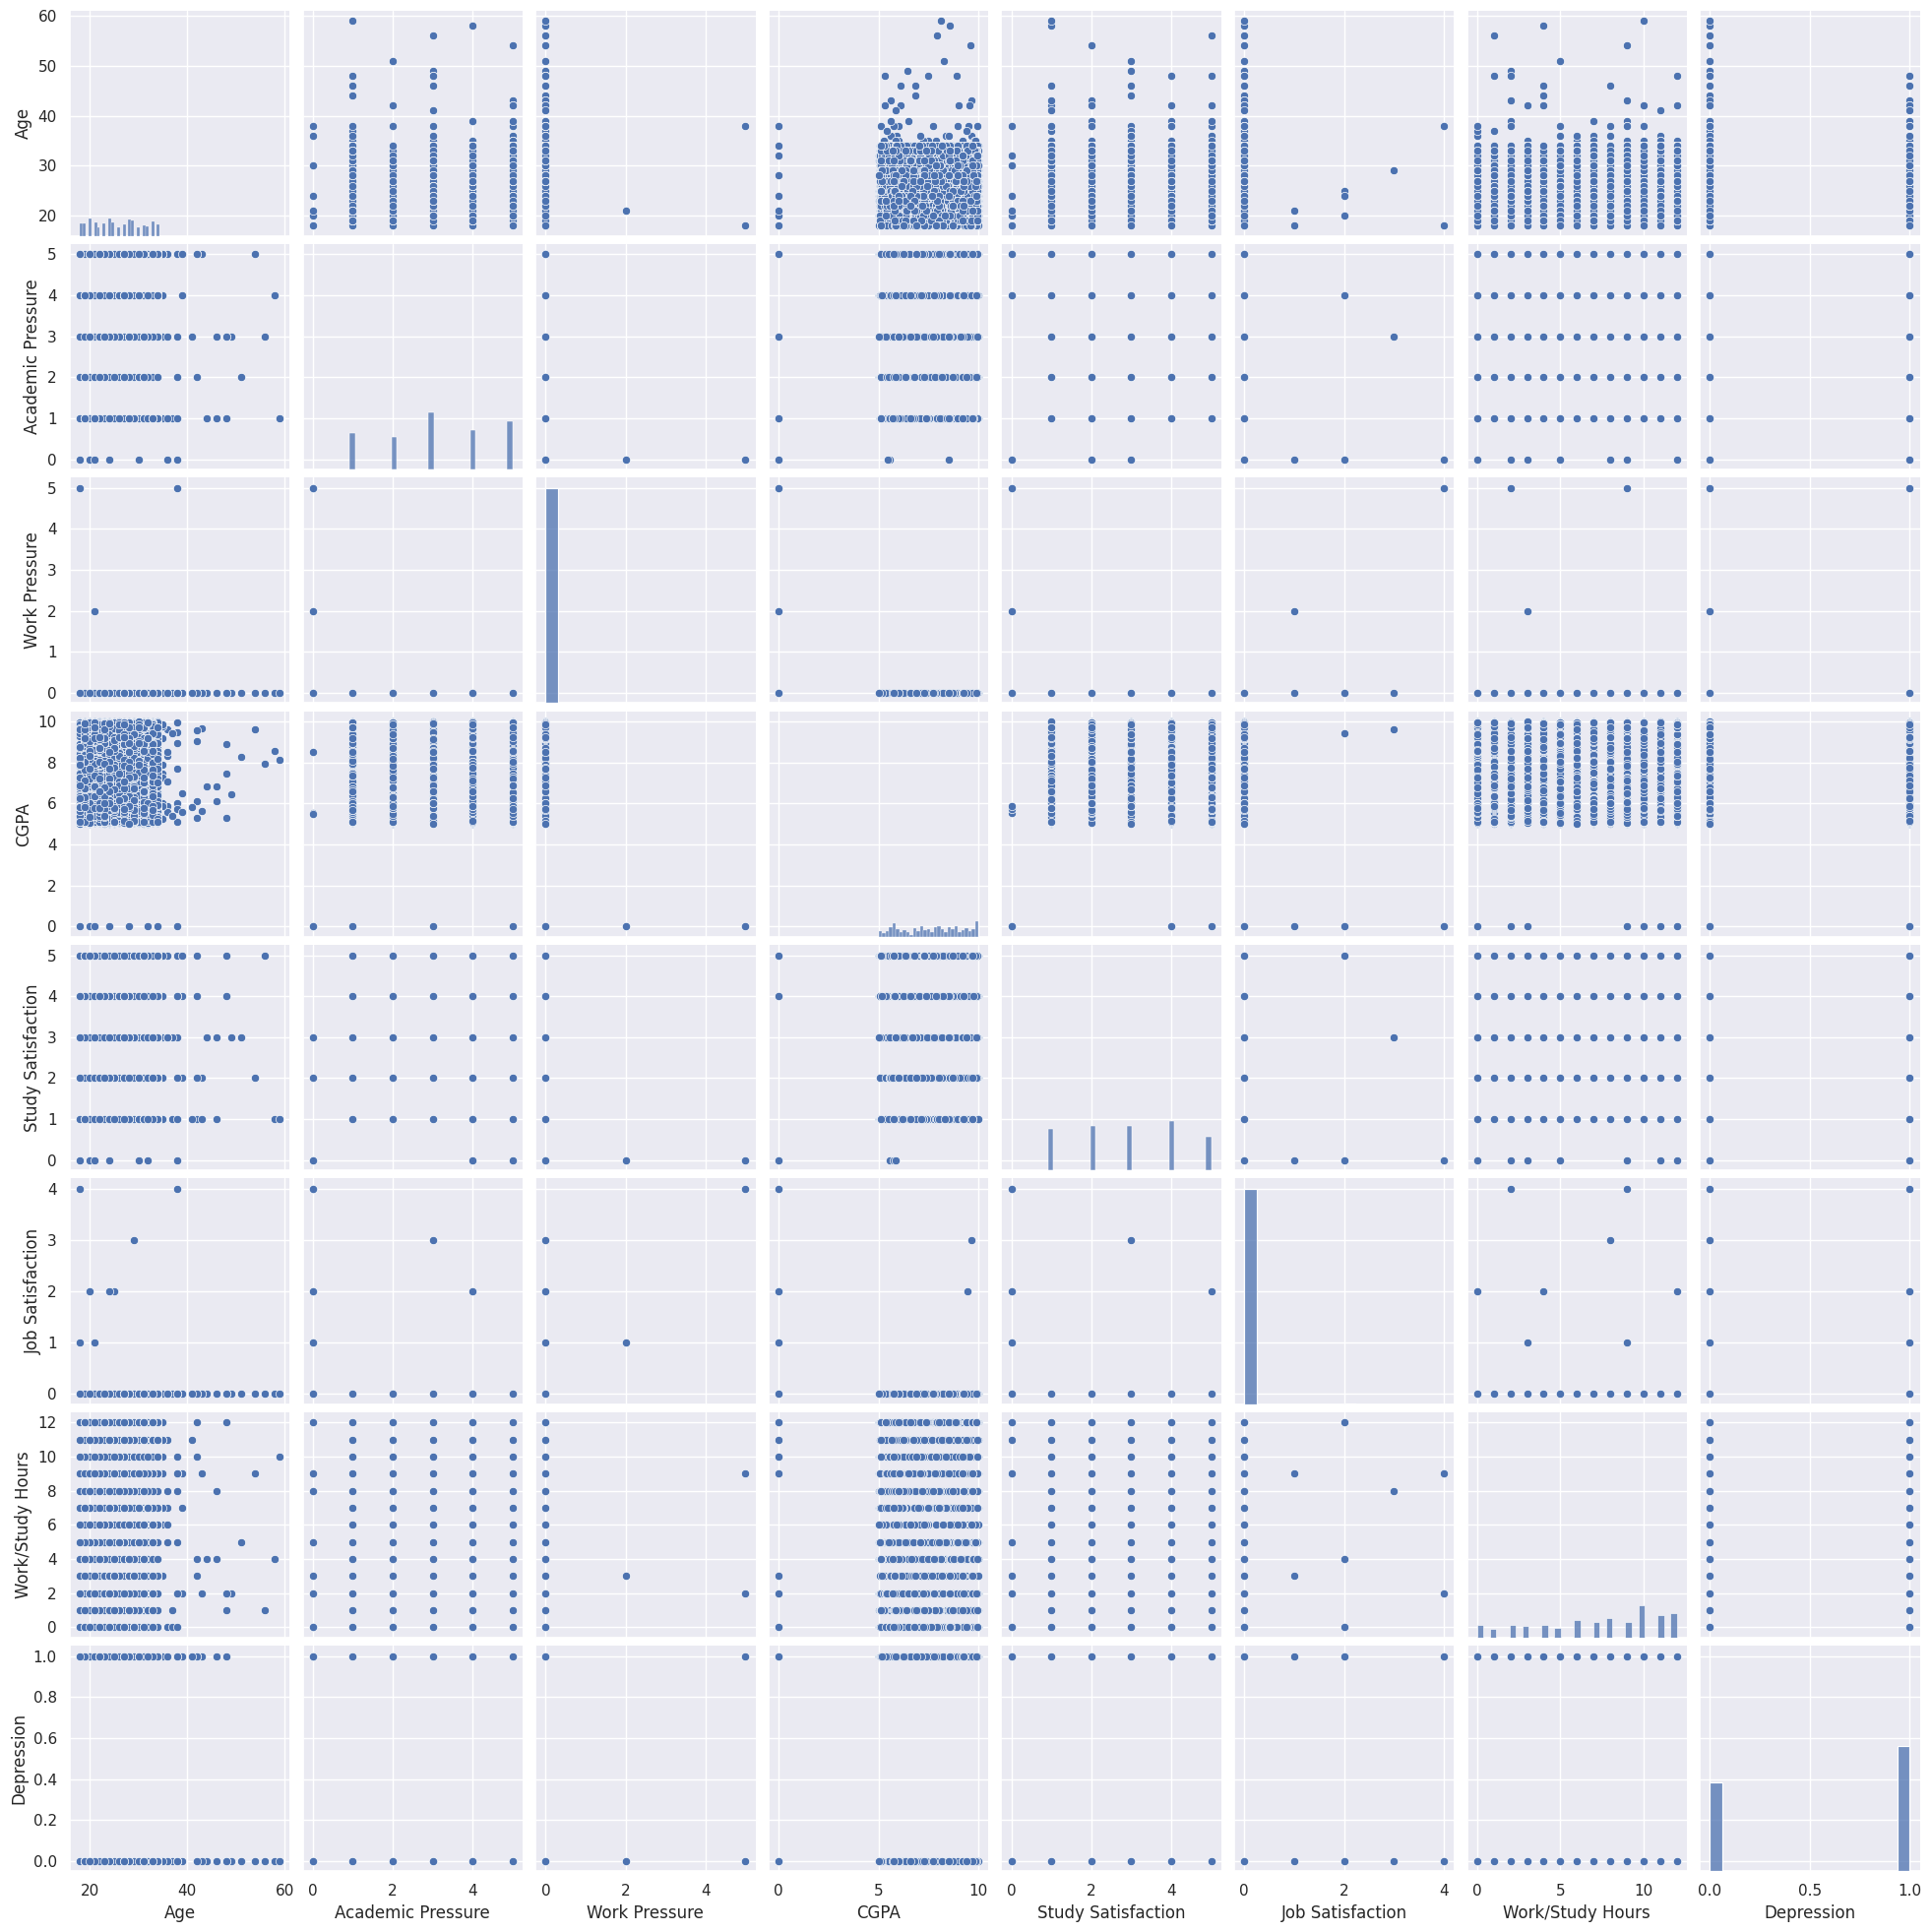

In [190]:
sns.pairplot(df_new)

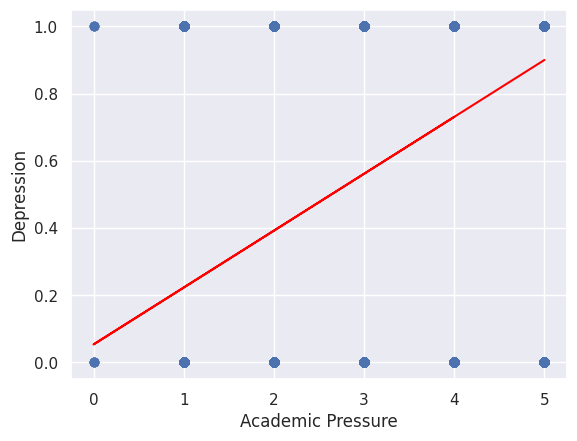

In [191]:
# Scatter plot with regression line
x = df_new['Academic Pressure']
y = df_new['Depression']

plt.scatter(df_new['Academic Pressure'], df_new['Depression'])
plt.xlabel('Academic Pressure')  # You can give the axis a custom label here
plt.ylabel('Depression')

# Obtain the slope (m) and intercept (b) of the regression line
m, b = np.polyfit(x, y, 1)

# Add linear regression line to scatter plot
plt.plot(x, m*x + b, color='red')
plt.show()


This diagram shows the relationship between Academic Pressure and Depression. It provides the insight that higher Academic Pressure increases the likelihood of students experiencing depression.

<ipython-input-192-6aaebf529adf>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Degree', data=df_new, palette='muted')


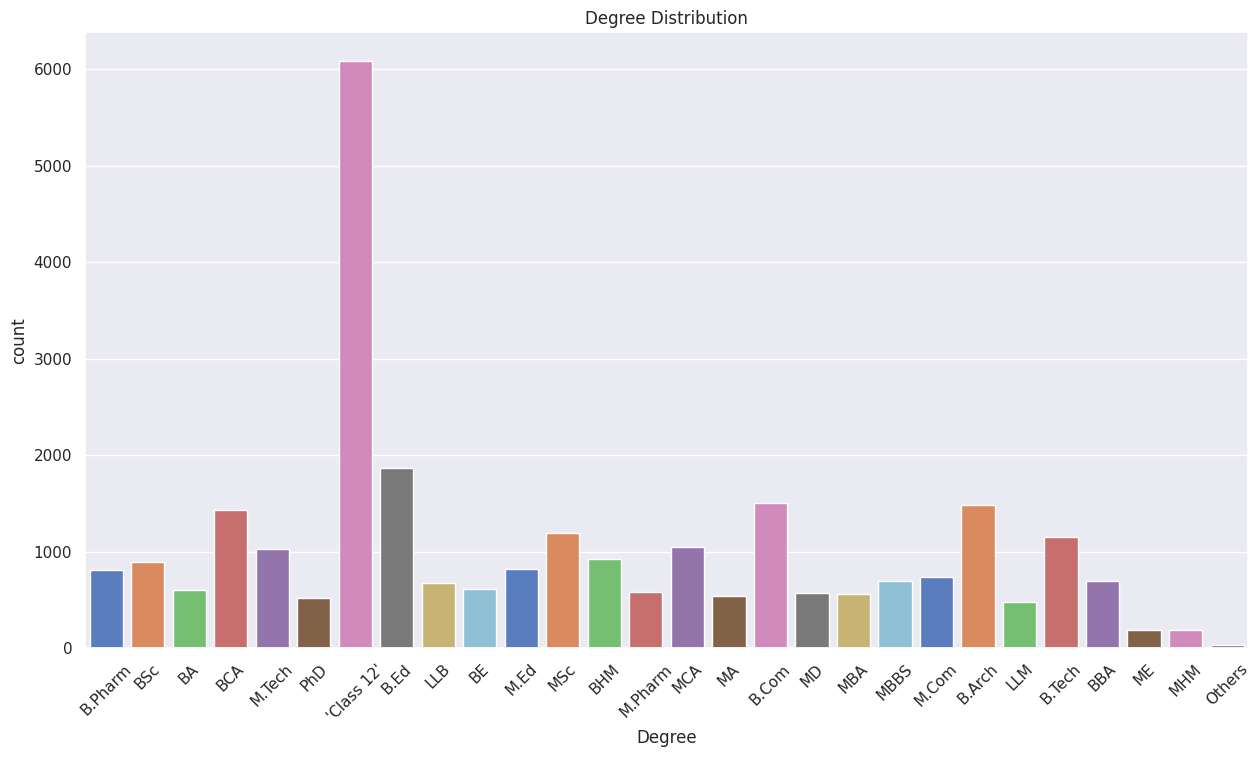

In [192]:
# Bar plot for Degree
plt.figure(figsize=(15, 8))
sns.countplot(x='Degree', data=df_new, palette='muted')
plt.title('Degree Distribution')
plt.xticks(rotation=45)
plt.show()


This diagram illustrates the variety in student degrees, showing the distribution of students across different academic programs.

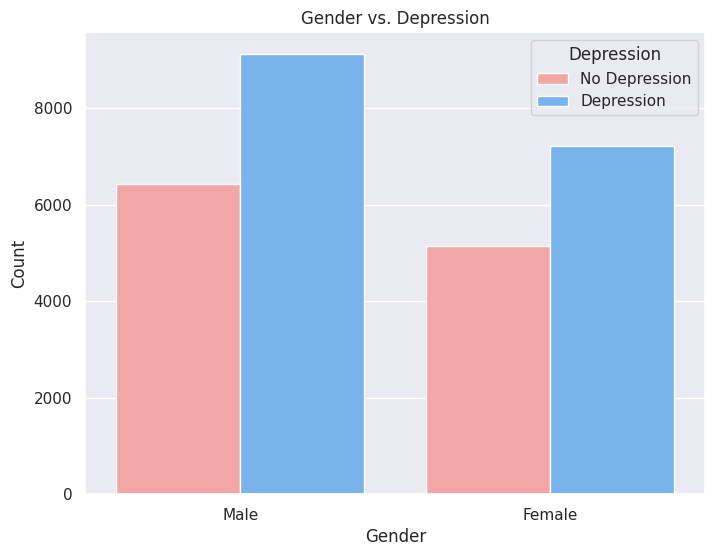

In [193]:
# Count plot for Gender vs. Depression
plt.figure(figsize=(8, 6))
custom_palette = ['#FF9999', '#66B3FF']
sns.countplot(x='Gender', hue='Depression', data=df_new, palette=custom_palette)
plt.title('Gender vs. Depression')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Depression', labels=['No Depression', 'Depression'])
plt.show()


This diagram illustrates the count of individuals based on gender and depression status. The data shows that for both males and females, the count of individuals experiencing depression is higher than those without depression. Furthermore, males appear to have a higher count of depression cases compared to females.

In [194]:
# Run the following codes to confirm data normality of the first input feature

# Confirmation of Data Normality using Shapiro-Wilk Test
from scipy.stats import shapiro
x1 = df_new['Age']
print("H0: Sample has normal distrbution")
# Normality test
stat, p = shapiro(x1)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# Interpret
alpha = 0.05
if p >= alpha:
 print('Sample looks Gaussian (fail to reject H0)')
else:
 print('Sample does not look Gaussian (reject H0)')

H0: Sample has normal distrbution
Statistics=0.950, p=0.000
Sample does not look Gaussian (reject H0)


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 27901.
  res = hypotest_fun_out(*samples, **kwds)


In [195]:
from sklearn.preprocessing import LabelEncoder

# Function to convert all object-type columns to numeric
def convert_object_to_numeric(df):
    # Initialize LabelEncoder
    encoder = LabelEncoder()

    # Select all object-type columns
    object_cols = df.select_dtypes(include=['object']).columns

    # Apply Label Encoding to each object-type column
    for col in object_cols:
        df[col] = encoder.fit_transform(df[col])

    return df

# Apply the function to your dataset
df_converted = convert_object_to_numeric(df_new)

# Display the dataframe after conversion
print("Data after converting object columns to numeric:")
print(df_converted.head())

# Verify data types
print("\nData types of columns:")
print(df_converted.dtypes)


Data after converting object columns to numeric:
   Gender   Age  Academic Pressure  Work Pressure  CGPA  Study Satisfaction  \
0       1  33.0                5.0            0.0  8.97                 2.0   
1       0  24.0                2.0            0.0  5.90                 5.0   
2       1  31.0                3.0            0.0  7.03                 5.0   
3       0  28.0                3.0            0.0  5.59                 2.0   
4       0  25.0                4.0            0.0  8.13                 3.0   

   Job Satisfaction  Sleep Duration  Dietary Habits  Degree  \
0               0.0               0               0       4   
1               0.0               0               1      11   
2               0.0               2               0       6   
3               0.0               1               1       8   
4               0.0               0               1      17   

   Have you ever had suicidal thoughts ?  Work/Study Hours  Financial Stress  \
0                

In [196]:
df_converted.head(10)

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,5.0,0.0,8.97,2.0,0.0,0,0,4,1,3.0,0,0,1
1,0,24.0,2.0,0.0,5.90,5.0,0.0,0,1,11,0,3.0,1,1,0
2,1,31.0,3.0,0.0,7.03,5.0,0.0,2,0,6,0,9.0,0,1,0
3,0,28.0,3.0,0.0,5.59,2.0,0.0,1,1,8,1,4.0,4,1,1
4,0,25.0,4.0,0.0,8.13,3.0,0.0,0,1,17,1,1.0,0,0,0
5,1,29.0,2.0,0.0,5.70,3.0,0.0,2,0,27,0,4.0,0,0,0
6,1,30.0,3.0,0.0,9.54,4.0,0.0,1,0,11,0,1.0,1,0,0
7,0,30.0,2.0,0.0,8.04,4.0,0.0,2,3,0,0,0.0,0,1,0
8,1,28.0,3.0,0.0,9.79,1.0,0.0,1,1,3,1,12.0,2,0,1
9,1,31.0,2.0,0.0,8.38,3.0,0.0,2,1,12,1,2.0,4,0,1


In [197]:
X = df_converted.iloc[:, :-1].values
y = df_converted.iloc[:, -1].values

In [198]:
from sklearn import preprocessing
mm_scaler = preprocessing.MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)
X_mm

array([[1.        , 0.36585366, 1.        , ..., 0.25      , 0.        ,
        0.        ],
       [0.        , 0.14634146, 0.4       , ..., 0.25      , 0.2       ,
        1.        ],
       [1.        , 0.31707317, 0.6       , ..., 0.75      , 0.        ,
        1.        ],
       ...,
       [1.        , 0.31707317, 0.6       , ..., 1.        , 0.2       ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.83333333, 0.8       ,
        0.        ],
       [1.        , 0.2195122 , 0.8       , ..., 0.16666667, 0.4       ,
        1.        ]])

In [199]:
import pandas as pd
from sklearn import preprocessing

# Separate features (X) and target (y)
X = df_converted.iloc[:, :-1].values  # Select all columns except the last one for features
y = df_converted.iloc[:, -1].values  # Select the last column for target

# Apply MinMaxScaler to rescale features
mm_scaler = preprocessing.MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)

# Print the scaled features
print("Scaled features (X):")
print(X_mm)

Scaled features (X):
[[1.         0.36585366 1.         ... 0.25       0.         0.        ]
 [0.         0.14634146 0.4        ... 0.25       0.2        1.        ]
 [1.         0.31707317 0.6        ... 0.75       0.         1.        ]
 ...
 [1.         0.31707317 0.6        ... 1.         0.2        0.        ]
 [0.         0.         1.         ... 0.83333333 0.8        0.        ]
 [1.         0.2195122  0.8        ... 0.16666667 0.4        1.        ]]


In [200]:
columns = df_converted.columns[:-1]  # Feature column names (excluding the target)
df_scaled_features = pd.DataFrame(X_mm, columns=columns)

print("\nDataframe of scaled features:")
df_scaled_features.head(10)


Dataframe of scaled features:


,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,1.0,0.365854,1.0,0.0,0.897,0.4,0.0,0.00,0.000000,0.148148,1.0,0.250000,0.0,0.0
1,0.0,0.146341,0.4,0.0,0.590,1.0,0.0,0.00,0.333333,0.407407,0.0,0.250000,0.2,1.0
2,1.0,0.317073,0.6,0.0,0.703,1.0,0.0,0.50,0.000000,0.222222,0.0,0.750000,0.0,1.0
3,0.0,0.243902,0.6,0.0,0.559,0.4,0.0,0.25,0.333333,0.296296,1.0,0.333333,0.8,1.0
4,0.0,0.170732,0.8,0.0,0.813,0.6,0.0,0.00,0.333333,0.629630,1.0,0.083333,0.0,0.0
5,1.0,0.268293,0.4,0.0,0.570,0.6,0.0,0.50,0.000000,1.000000,0.0,0.333333,0.0,0.0
6,1.0,0.292683,0.6,0.0,0.954,0.8,0.0,0.25,0.000000,0.407407,0.0,0.083333,0.2,0.0
7,0.0,0.292683,0.4,0.0,0.804,0.8,0.0,0.50,1.000000,0.000000,0.0,0.000000,0.0,1.0
8,1.0,0.243902,0.6,0.0,0.979,0.2,0.0,0.25,0.333333,0.111111,1.0,1.000000,0.4,0.0
9,1.0,0.317073,0.4,0.0,0.838,0.6,0.0,0.50,0.333333,0.444444,1.0,0.166667,0.8,0.0


#Model Estimation

In [201]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# Split data into train/test sets
# Using 80% for training, 20% for test
X_train, X_test, y_train, y_test = train_test_split(X_mm, y, test_size=0.2, random_state=42)

# 1. Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# 2. Support Vector Machine (SVM) Model
svm_model = SVC()
svm_model.fit(X_train, y_train)

# 3. Random Forest Model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# 4. Multi-layer Perceptron (MLP) Neural Network
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)
mlp_model.fit(X_train, y_train)  # Train the neural network

MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)

# Model Evaluation

Using four metrics: Accuracy, Precision, Recall, and F1-score.

## Evaluate Performance using Default Parameters

In [202]:
# Import required libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a function to calculate and print evaluation metrics
def print_metrics(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{model_name} Metrics:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")

 # Return all metrics in a dictionary
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

In [203]:
# Predict and evaluate performance for each model

# Logistic Regression
y_pred_lr = lr_model.predict(X_test)
lr_metrics = print_metrics(y_test, y_pred_lr, "Logistic Regression")

# SVM
y_pred_svm = svm_model.predict(X_test)
svm_metrics = print_metrics(y_test, y_pred_svm, "SVM")

# Random Forest
y_pred_rf = rf_model.predict(X_test)
rf_metrics = print_metrics(y_test, y_pred_rf, "Random Forest")

# MLP
y_pred_mlp = mlp_model.predict(X_test)
mlp_metrics = print_metrics(y_test, y_pred_mlp, "MLP Neural Network")


Logistic Regression Metrics:
  Accuracy : 0.8377
  Precision: 0.8510
  Recall   : 0.8731
  F1 Score : 0.8619

SVM Metrics:
  Accuracy : 0.8348
  Precision: 0.8420
  Recall   : 0.8805
  F1 Score : 0.8608

Random Forest Metrics:
  Accuracy : 0.8258
  Precision: 0.8423
  Recall   : 0.8610
  F1 Score : 0.8516

MLP Neural Network Metrics:
  Accuracy : 0.8361
  Precision: 0.8568
  Recall   : 0.8613
  F1 Score : 0.8591




---



Metric Formulas:
Accuracy = (TP + TN) / (TP + FP + FN + TN)
→ Proportion of total correct predictions

Precision = TP / (TP + FP)
→ Of predicted positives, how many are truly positive

Recall = TP / (TP + FN)
→ Of actual positives, how many did the model catch

F1 Score = 2 × (Precision × Recall) / (Precision + Recall)
→ Harmonic mean of precision and recall



---




**Logistic Regression** had 87.31% recall and 85.10% precision, meaning it correctly identified most depressed students and didn’t overpredict, making it both accurate and interpretable.


**SVM** had the highest recall (88.05%), so it missed the fewest actual cases, which is especially important in mental health, where failing to detect someone in need can have serious consequences.


**Random Forest** had 86.10% recall and 84.23% precision — decent, but it didn’t outperform others on any key metric.


**MLP** achieved the highest F1-score (85.91%) and precision (85.68), showing it was best at balancing false positives and false negatives.

## Tune Parameters using GridSearchCV

In [205]:
# Import required library
from sklearn.model_selection import GridSearchCV

In [206]:
# Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']})

In [207]:
# SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1, 1]})

In [208]:
# Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [50, 100]})

In [209]:
# MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd']
}

grid_mlp = GridSearchCV(MLPClassifier(max_iter=1000), param_grid_mlp, cv=3)
grid_mlp.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=MLPClassifier(max_iter=1000),
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50,), (100,)],
                         'solver': ['adam', 'sgd']})

## Report the optimal value of each parameter for each model.

In [214]:
# Tuned Logistic Regression
print("Best parameter - Logistic Regression:", grid_lr.best_params_)

#Tuned SVM
print("\nBest parameter - SVM:", grid_svm.best_params_)

#Tuned Random Forest
print("\nBest parameter - Random Forest:", grid_rf.best_params_)

#Tuned MLP
print("\nBest parameter - MLP Classifier:", grid_mlp.best_params_)

Best parameter - Logistic Regression: {'C': 10, 'solver': 'lbfgs'}

Best parameter - SVM: {'C': 10, 'gamma': 0.1}

Best parameter - Random Forest: {'max_depth': 10, 'n_estimators': 100}

Best parameter - MLP Classifier: {'activation': 'relu', 'hidden_layer_sizes': (50,), 'solver': 'adam'}


In [219]:
# Predict and evaluate performance for each model

# Tuned Logistic Regression
y_pred_lr_t = grid_lr.predict(X_test)
tuned_lr_metrics_t = print_metrics(y_test, y_pred_lr_t, "Tuned Logistic Regression")

#Tuned SVM
y_pred_svm_t = grid_svm.predict(X_test)
tuned_svm_metrics_t = print_metrics(y_test, y_pred_svm_t, "Tuned SVM")

#Tuned Random Forest
y_pred_rf_t = grid_rf.predict(X_test)
tuned_rf_metrics_t = print_metrics(y_test, y_pred_rf_t, "Tuned Random Forest")

#Tuned MLP
y_pred_mlp_t = grid_mlp.predict(X_test)
tuned_mlp_metrics_t = print_metrics(y_test, y_pred_mlp_t, "Tuned MLP")


Tuned Logistic Regression Metrics:
  Accuracy : 0.8375
  Precision: 0.8509
  Recall   : 0.8728
  F1 Score : 0.8617

Tuned SVM Metrics:
  Accuracy : 0.8359
  Precision: 0.8377
  Recall   : 0.8894
  F1 Score : 0.8628

Tuned Random Forest Metrics:
  Accuracy : 0.8337
  Precision: 0.8435
  Recall   : 0.8758
  F1 Score : 0.8594

Tuned MLP Metrics:
  Accuracy : 0.8380
  Precision: 0.8543
  Recall   : 0.8691
  F1 Score : 0.8616


## Compare Before vs After Tuning

In [221]:
blank_row = {
    "Model": "", "Accuracy": "", "Precision": "", "Recall": "", "F1-Score": ""
} # Create a blank row for better visulazation

# Combine metrics for all models
all_results_df = pd.DataFrame([
    lr_metrics, tuned_lr_metrics, blank_row,
    svm_metrics, tuned_svm_metrics, blank_row,
    rf_metrics, tuned_rf_metrics, blank_row,
    mlp_metrics, tuned_mlp_metrics, blank_row
])

# Display the full comparison of all models
print("\n                      All Model Metrics Comparison\n")
print(all_results_df)


                      All Model Metrics Comparison

                        Model  Accuracy Precision    Recall  F1-Score
0         Logistic Regression  0.837664  0.850993   0.87307   0.86189
1   Tuned Logistic Regression  0.837484  0.850949  0.872761  0.861717
2                                                                    
3                         SVM  0.834797  0.841996  0.880482  0.860809
4                   Tuned SVM  0.835872  0.837696  0.889438  0.862792
5                                                                    
6               Random Forest  0.825838  0.842296  0.861025  0.851558
7         Tuned Random Forest  0.833722  0.843546  0.875849  0.859394
8                                                                    
9          MLP Neural Network  0.836051  0.856836  0.861334  0.859079
10       Tuned MLP Classifier  0.838022  0.854281  0.869055  0.861604
11                                                                   


**Logistic Regression** showed minimal change after tuning. Accuracy slightly dropped from 0.837664 to 0.837484, and the F1-score from 0.861890 to 0.861717, indicating that its default settings were already effective.

→ Tuning did not improve performance.


**SVM** improved across all metrics. Accuracy increased to 0.835872, recall rose from 0.880482 to 0.889438, and F1-score from 0.860809 to 0.862792, showing better detection of true cases with good balance.

→ Tuning improved performance.

**Random Forest** showed gains. Accuracy went from 0.825838 to 0.833722, and F1-score from 0.851558 to 0.859394, mainly due to improved recall, while precision remained stable.

→ Tuning improved performance.

**MLP** changed slightly. F1-score increased from 0.859079 to 0.861604, with a small recall gain and a slight dip in precision.

→ Tuning had minimal impact.

## Explain whether the models suffer from underfitting or overfitting.

In [228]:
# Create a list of dictionaries containing accuracy for each model on Train and Test sets
accuracy_data = [
    {"Model": "Logistic Regression", "Set": "Train", "Accuracy": accuracy_score(y_train, lr_model.predict(X_train))},
    {"Model": "Logistic Regression", "Set": "Test", "Accuracy": accuracy_score(y_test, lr_model.predict(X_test))},

    {"Model": "Tuned Logistic Regression", "Set": "Train", "Accuracy": accuracy_score(y_train, grid_lr.predict(X_train))},
    {"Model": "Tuned Logistic Regression", "Set": "Test", "Accuracy": accuracy_score(y_test, grid_lr.predict(X_test))},

    {"Model": "SVM", "Set": "Train", "Accuracy": accuracy_score(y_train, svm_model.predict(X_train))},
    {"Model": "SVM", "Set": "Test", "Accuracy": accuracy_score(y_test, svm_model.predict(X_test))},

    {"Model": "Tuned SVM", "Set": "Train", "Accuracy": accuracy_score(y_train, grid_svm.predict(X_train))},
    {"Model": "Tuned SVM", "Set": "Test", "Accuracy": accuracy_score(y_test, grid_svm.predict(X_test))},

    {"Model": "Random Forest", "Set": "Train", "Accuracy": accuracy_score(y_train, rf_model.predict(X_train))},
    {"Model": "Random Forest", "Set": "Test", "Accuracy": accuracy_score(y_test, rf_model.predict(X_test))},

    {"Model": "Tuned Random Forest", "Set": "Train", "Accuracy": accuracy_score(y_train, grid_rf.predict(X_train))},
    {"Model": "Tuned Random Forest", "Set": "Test", "Accuracy": accuracy_score(y_test, grid_rf.predict(X_test))},

    {"Model": "MLP Neural Network", "Set": "Train", "Accuracy": accuracy_score(y_train, mlp_model.predict(X_train))},
    {"Model": "MLP Neural Network", "Set": "Test", "Accuracy": accuracy_score(y_test, mlp_model.predict(X_test))},

    {"Model": "Tuned MLP Neural Network", "Set": "Train", "Accuracy": accuracy_score(y_train, grid_mlp.predict(X_train))},
    {"Model": "Tuned MLP Neural Network", "Set": "Test", "Accuracy": accuracy_score(y_test, grid_mlp.predict(X_test))},
]


# Convert the list of accuracy records into a pandas DataFrame
accuracy_df = pd.DataFrame(accuracy_data)

# Display the DataFrame
display(accuracy_df)


,Model,Set,Accuracy
0,Logistic Regression,Train,0.847849
1,Logistic Regression,Test,0.837664
2,Tuned Logistic Regression,Train,0.848029
3,Tuned Logistic Regression,Test,0.837484
4,SVM,Train,0.853271
5,SVM,Test,0.834797
6,Tuned SVM,Train,0.852195
7,Tuned SVM,Test,0.835872
8,Random Forest,Train,1.000000
9,Random Forest,Test,0.825838


**Model Fitting Analysis:**

Most models, including Logistic Regression, Tuned Logistic Regression, SVM,  MLP, and Tuned MLP, were classified as Balanced.

Their training and testing accuracies were both above 80%, and the accuracy gap between them was smaller than 5%. This indicates that these models are learning effectively, generalizing well to new data without overfitting or underfitting.




---




On the other hand, the Random Forest model showed clear signs of Overfitting. It achieved 100% accuracy on the training set but only 82.6% on the test set — a significant gap. This suggests the model memorized the training data rather than learning patterns that generalize to unseen data.


The Tuned Random Forest also exhibited overfitting, but less severe, with a training accuracy of 88.9% and test accuracy of 83.3%.